In [1]:
import numpy as np
import random
import tensorflow as tf
import os

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# Load your master dataset again fresh
df_full = pd.read_csv("/content/Final_Master_Dataset.csv")


In [2]:
infl_df = df_full[[
    "Country",
    "Year",
    "D_Expenditure_GDP",
    "Inflation_Annual",
    "GDP_Growth_Annual",
    "GDP_PerCapita_Growth_Annual",
    "Population"
]].copy()

infl_df.columns = [
    "Country",
    "Year",
    "Defense_GDP",
    "Inflation",
    "GDP_Growth",
    "GDP_PC_Growth",
    "Population"
]

infl_df = infl_df.sort_values(["Country", "Year"]).reset_index(drop=True)

# Basic data:
infl_df.info()
infl_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        155 non-null    object 
 1   Year           155 non-null    int64  
 2   Defense_GDP    155 non-null    float64
 3   Inflation      155 non-null    float64
 4   GDP_Growth     155 non-null    float64
 5   GDP_PC_Growth  155 non-null    float64
 6   Population     155 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 8.6+ KB


,Year,Defense_GDP,Inflation,GDP_Growth,GDP_PC_Growth,Population
count,155.000000,155.000000,155.000000,155.000000,155.000000,1.550000e+02
mean,2009.000000,2.778980,7.941282,3.366688,2.860431,3.806592e+08
std,8.973265,1.026659,30.073988,4.090402,4.066489,4.838115e+08
min,1994.000000,1.605260,-1.401470,-12.569800,-12.539800,5.786574e+07
25%,2001.000000,1.924853,1.569155,1.673178,1.070603,6.521442e+07
50%,2009.000000,2.422716,2.292840,2.714064,2.117365,1.446486e+08
75%,2017.000000,3.505406,4.584113,5.307406,5.535516,3.254810e+08
max,2024.000000,7.052339,307.722600,14.149990,13.555370,1.412360e+09


In [3]:
# Handle missing values:
infl_df = infl_df.groupby("Country").apply(
    lambda x: x.interpolate(method="linear")
).reset_index(drop=True)

infl_df = infl_df.dropna().reset_index(drop=True)

/tmp/ipython-input-3581258518.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-3581258518.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-3581258518.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-3581258518.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp

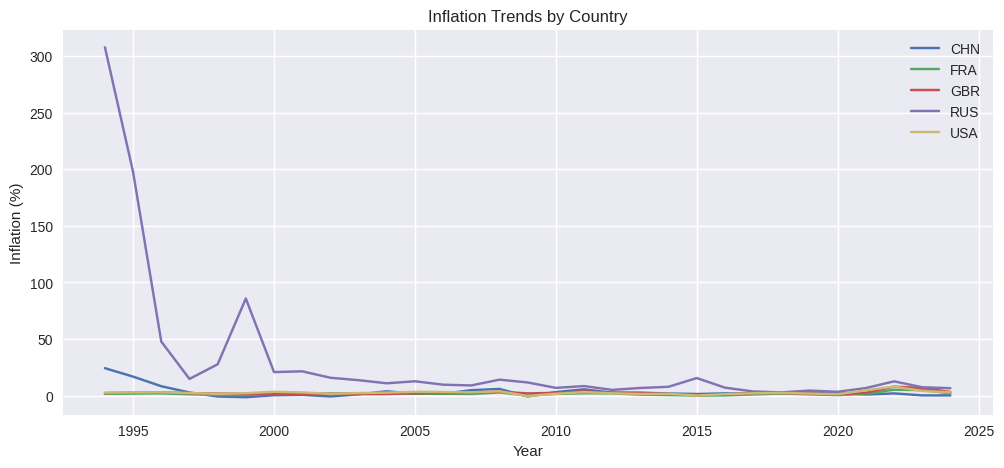

In [4]:
# Exploratory Data Analysis (EDA):
# Inflation-trend per country:

plt.figure(figsize=(12,5))

for country in infl_df["Country"].unique():
    cdf = infl_df[infl_df["Country"] == country]
    plt.plot(cdf["Year"], cdf["Inflation"], label=country)

plt.title("Inflation Trends by Country")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend()
plt.show()

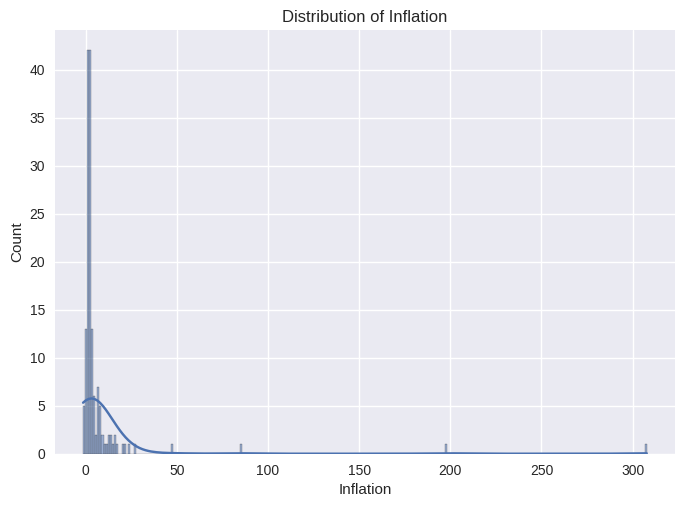

In [5]:
# Distribution of inflation:
sns.histplot(infl_df["Inflation"], kde=True)
plt.title("Distribution of Inflation")
plt.show()

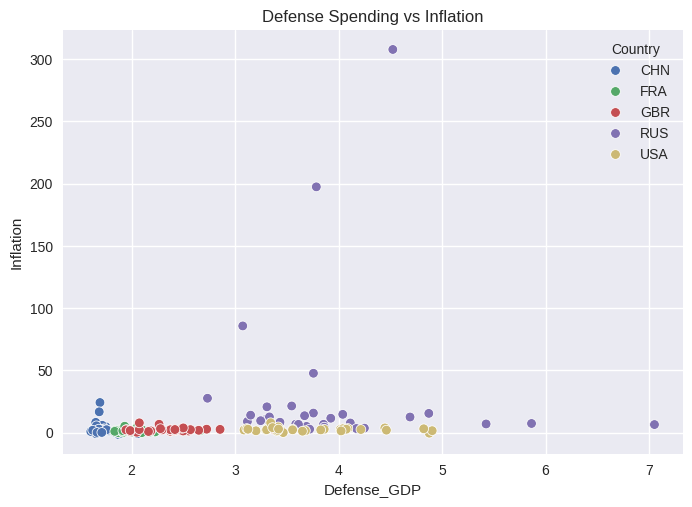

In [6]:
# Defence vs Inflation relationship:
sns.scatterplot(
    data=infl_df,
    x="Defense_GDP",
    y="Inflation",
    hue="Country"
)
plt.title("Defense Spending vs Inflation")
plt.show()

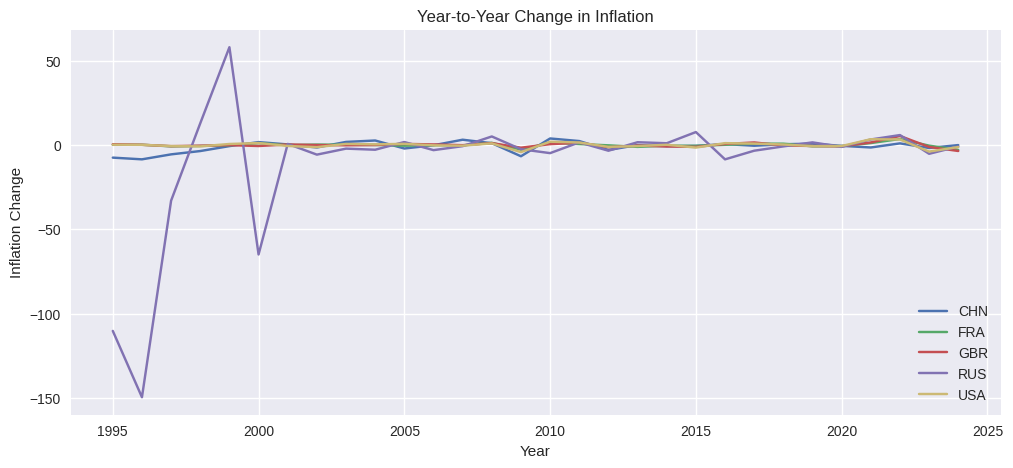

In [7]:
# Inflation change:
infl_df["Inflation_Diff"] = infl_df.groupby("Country")["Inflation"].diff()

plt.figure(figsize=(12,5))
for country in infl_df["Country"].unique():
    cdf = infl_df[infl_df["Country"] == country]
    plt.plot(cdf["Year"], cdf["Inflation_Diff"], label=country)

plt.title("Year-to-Year Change in Inflation")
plt.xlabel("Year")
plt.ylabel("Inflation Change")
plt.legend()
plt.show()

In [8]:
# Clean-modelling starts from here..
infl_df = df_full[[
    "Country",
    "Year",
    "D_Expenditure_GDP",
    "Inflation_Annual",
    "GDP_PerCapita_Growth_Annual",
    "Population",
    "GDP_Growth_Annual",
    "Unemployment_Total_of_TLF"
]].copy()

infl_df.columns = [
    "Country",
    "Year",
    "Defense_GDP",
    "Inflation",
    "GDP_PC_Growth",
    "Population",
    "GDP_Growth",
    "Unemployment_Total"
]

infl_df = infl_df.sort_values(["Country", "Year"]).reset_index(drop=True)

# Have to remove extreme 1990s russian-hyperinflation, so we remove 1994-1999 region:
infl_df = infl_df[infl_df["Year"] >= 2000].reset_index(drop=True)

# Create delta-targets:
infl_df["Inflation_Delta"] = (
    infl_df.groupby("Country")["Inflation"].diff()
)

infl_df = infl_df.dropna().reset_index(drop=True)

In [9]:
# Create lag-featuures:
infl_df["Infl_lag1"] = infl_df.groupby("Country")["Inflation"].shift(1)
infl_df["Infl_lag2"] = infl_df.groupby("Country")["Inflation"].shift(2)
infl_df["Infl_lag3"] = infl_df.groupby("Country")["Inflation"].shift(3)
infl_df["Infl_lag4"] = infl_df.groupby("Country")["Inflation"].shift(4)


infl_df = infl_df.dropna().reset_index(drop=True)

# Encode 'Country':
from sklearn.preprocessing import LabelEncoder

le_infl = LabelEncoder()
infl_df["Country_ID"] = le_infl.fit_transform(infl_df["Country"])

# Train-Test split:
train_infl = infl_df[infl_df["Year"] <= 2020]
test_infl  = infl_df[(infl_df["Year"] >= 2021) & (infl_df["Year"] <= 2024)]

# Define features and target:
INPUT_FEATURES_INFL = [
    "Country_ID",
    "Defense_GDP",
    "GDP_PC_Growth",
    "Population",
    "GDP_Growth",
    "Unemployment_Total",
    "Infl_lag1",
    "Infl_lag2"
]

TARGET_INFL = "Inflation_Delta"

In [10]:
# Scaling:
from sklearn.preprocessing import MinMaxScaler

X_scaler_infl = MinMaxScaler()
y_scaler_infl = MinMaxScaler()

X_train_infl = X_scaler_infl.fit_transform(train_infl[INPUT_FEATURES_INFL])
y_train_infl = y_scaler_infl.fit_transform(train_infl[[TARGET_INFL]])

train_scaled_infl = train_infl.copy()
train_scaled_infl[INPUT_FEATURES_INFL] = X_train_infl
train_scaled_infl[[TARGET_INFL]] = y_train_infl

# Create sequences (TIME STEPS=5): (Not for test)

import numpy as np

def create_sequences_per_country(df, input_cols, target_col, time_steps=5):
    X, y = [], []

    for country in df["Country"].unique():
        country_df = df[df["Country"] == country].sort_values("Year")

        data_X = country_df[input_cols].values
        data_y = country_df[[target_col]].values

        for i in range(len(country_df) - time_steps):
            X.append(data_X[i:i+time_steps])
            y.append(data_y[i+time_steps])

    return np.array(X), np.array(y)




TIME_STEPS = 5

X_train_seq_infl, y_train_seq_infl = create_sequences_per_country(
    train_scaled_infl,
    INPUT_FEATURES_INFL,
    TARGET_INFL,
    TIME_STEPS
)

print("X shape:", X_train_seq_infl.shape)
print("y shape:", y_train_seq_infl.shape)



X shape: (55, 5, 8)
y shape: (55, 1)


In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model_infl = Sequential([
    LSTM(32, return_sequences=True, input_shape=(TIME_STEPS, X_train_seq_infl.shape[2])),
    LSTM(16),
    Dense(1)
])

model_infl.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber()
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_infl = model_infl.fit(
    X_train_seq_infl,
    y_train_seq_infl,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - loss: 0.1275 - val_loss: 0.1306
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0827 - val_loss: 0.0826
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0487 - val_loss: 0.0445
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0244 - val_loss: 0.0177
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0115 - val_loss: 0.0044
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0108 - val_loss: 0.0024
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0153 - val_loss: 0.0029
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0152 - val_loss: 0.0023
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0116 - val_loss: 0.0026
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0091 - val_loss: 0.0039
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0086 - val_loss: 0.0050
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0087 - val_loss: 0.0051
Epoch 13/50

In [12]:
# Create evaluation dataset:
# Use last 9 years to allow 5-step windows..
eval_df = infl_df[infl_df["Year"] >= 2016].copy()

# Scale inputs..
eval_scaled = eval_df.copy()
eval_scaled[INPUT_FEATURES_INFL] = X_scaler_infl.transform(
    eval_df[INPUT_FEATURES_INFL]
)

eval_scaled[[TARGET_INFL]] = y_scaler_infl.transform(
    eval_df[[TARGET_INFL]]
)

# Create sequences:
X_eval_seq, y_eval_seq = create_sequences_per_country(
    eval_scaled,
    INPUT_FEATURES_INFL,
    TARGET_INFL,
    TIME_STEPS
)

print("Eval sequence shape:", X_eval_seq.shape)

y_pred_scaled = model_infl.predict(X_eval_seq)

y_pred_delta = y_scaler_infl.inverse_transform(y_pred_scaled)
y_actual_delta = y_scaler_infl.inverse_transform(y_eval_seq)

Eval sequence shape: (20, 5, 8)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


In [13]:
# Extract years aligned with sequences
years = []

for country in eval_scaled["Country"].unique():
    country_df = eval_scaled[eval_scaled["Country"] == country].sort_values("Year")

    for i in range(len(country_df) - TIME_STEPS):
        years.append(country_df["Year"].values[i + TIME_STEPS])

years = np.array(years)

# Keep only 2021–2024
mask = (years >= 2021) & (years <= 2024)

y_pred_delta = y_pred_delta[mask]
y_actual_delta = y_actual_delta[mask]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_actual_delta, y_pred_delta)
rmse = np.sqrt(mean_squared_error(y_actual_delta, y_pred_delta))
r2 = r2_score(y_actual_delta, y_pred_delta)

print("Inflation Delta Evaluation (2021–2024)")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Inflation Delta Evaluation (2021–2024)
MAE: 2.8267132232898775
RMSE: 3.3830628524063906
R²: -0.2372337556971933


In [14]:
# Save the Model:
model_infl.save("inflation_delta_lstm.h5")